# HavenRL — DQN Training Notebook
*"When Indian markets crash, where does Indian money hide?"*

A Deep Q-Network agent trained on India's three classic safe-haven assets:
Gold ETF, Silver ETF, and Bharat Bond ETF. Backtesting only — fake money on historical data.

---

## Install Dependencies

In [2]:
!pip install yfinance gym torch numpy pandas -q

## Imports

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import json
import warnings
warnings.filterwarnings("ignore")

## Fetch and Prepare Data

### 1. Experimenting with Data Fetching
*(Explored silver ETF options — SILVERBEES.NS, SILVERIETF.NS, SILVER.NS etc. All silver ETFs in India started trading only around 2021–2022, causing the full dataset to shrink to 715 rows. Replaced with LIQUIDBEES.NS which has data from 2018.)*

In [3]:
ASSETS = {
    "GOLDBEES.NS": "Gold ETF",
    "SILVERBEES.NS": "Silver ETF",
    "EBBETF0430.NS": "Bharat Bond ETF"
}

TRAIN_START = "2018-01-01"
TRAIN_END   = "2022-12-31"
TEST_START  = "2023-01-01"
TEST_END    = "2024-12-31"

def fetch_data(ticker, start, end):
    df = yf.download(ticker, start=start, end=end, progress=False)
    if df.empty:
        raise ValueError(f"No data returned for {ticker}. Check the ticker or date range.")
    return df[["Close"]].rename(columns={"Close": ticker})

# Download all 3 assets in one go (2018–2024)
raw_frames = []
for ticker in ASSETS:
    print(f"Fetching {ticker}...")
    raw_frames.append(fetch_data(ticker, "2018-01-01", "2024-12-31"))

# Merge on date — inner join keeps only dates all 3 assets share
full_df = pd.concat(raw_frames, axis=1).dropna()
print(f"\nFull dataset shape: {full_df.shape}")
print(f"Date range: {full_df.index[0].date()} → {full_df.index[-1].date()}")
print(full_df.tail())

Fetching GOLDBEES.NS...
Fetching SILVERBEES.NS...
Fetching EBBETF0430.NS...

Full dataset shape: (715, 3)
Date range: 2022-02-04 → 2024-12-30
Price      GOLDBEES.NS SILVERBEES.NS EBBETF0430.NS
Ticker     GOLDBEES.NS SILVERBEES.NS EBBETF0430.NS
Date                                              
2024-12-23   63.970001     85.489998   1437.020020
2024-12-24   63.680000     85.300003   1441.199951
2024-12-26   64.000000     85.430000   1438.329956
2024-12-27   64.209999     85.709999   1438.550049
2024-12-30   64.000000     84.949997   1437.969971


In [4]:
for ticker in ASSETS:
    df = yf.download(ticker, start="2018-01-01", end="2024-12-31", progress=False)
    print(f"{ticker}: {len(df)} rows, from {df.index[0].date()} to {df.index[-1].date()}")

GOLDBEES.NS: 1726 rows, from 2018-01-01 to 2024-12-30
SILVERBEES.NS: 715 rows, from 2022-02-04 to 2024-12-30
EBBETF0430.NS: 1238 rows, from 2019-12-30 to 2024-12-30


In [5]:
df = yf.download("SILVERIETF.NS", start="2018-01-01", end="2024-12-31", progress=False)
print(f"SILVERIETF.NS: {len(df)} rows, from {df.index[0].date()} to {df.index[-1].date()}")

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['SILVERIETF.NS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2018-01-01 -> 2024-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1514745000, endDate = 1735583400")')


IndexError: index 0 is out of bounds for axis 0 with size 0

In [6]:
silver_options = ["SILVER.NS", "SILVERBEES.BO", "ISILVER.NS", "SILVRETF.NS"]

for ticker in silver_options:
    try:
        df = yf.download(ticker, start="2018-01-01", end="2024-12-31", progress=False)
        if not df.empty:
            print(f"✅ {ticker}: {len(df)} rows, from {df.index[0].date()} to {df.index[-1].date()}")
        else:
            print(f"❌ {ticker}: empty")
    except:
        print(f"❌ {ticker}: error")

✅ SILVER.NS: 717 rows, from 2022-01-31 to 2024-12-30


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['SILVERBEES.BO']: YFPricesMissingError('possibly delisted; no price data found  (1d 2018-01-01 -> 2024-12-31)')


❌ SILVERBEES.BO: empty


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ISILVER.NS"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ISILVER.NS']: YFTzMissingError('possibly delisted; no timezone found')


❌ ISILVER.NS: empty


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: SILVRETF.NS"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['SILVRETF.NS']: YFTzMissingError('possibly delisted; no timezone found')


❌ SILVRETF.NS: empty


In [7]:
df = yf.download("LIQUIDBEES.NS", start="2018-01-01", end="2024-12-31", progress=False)
print(f"LIQUIDBEES.NS: {len(df)} rows, from {df.index[0].date()} to {df.index[-1].date()}")

LIQUIDBEES.NS: 1726 rows, from 2018-01-01 to 2024-12-30


### 2. Actual Data Fetch — Gold ETF (GOLDBEES.NS), Liquid ETF (LIQUIDBEES.NS), Bharat Bond ETF (EBBETF0430.NS)

In [8]:
ASSETS = {
    "GOLDBEES.NS": "Gold ETF",
    "LIQUIDBEES.NS": "Liquid ETF",
    "EBBETF0430.NS": "Bharat Bond ETF"
}

TRAIN_START = "2018-01-01"
TRAIN_END   = "2022-12-31"
TEST_START  = "2023-01-01"
TEST_END    = "2024-12-31"

def fetch_data(ticker, start, end):
    df = yf.download(ticker, start=start, end=end, progress=False)
    if df.empty:
        raise ValueError(f"No data returned for {ticker}. Check the ticker or date range.")
    return df[["Close"]].rename(columns={"Close": ticker})

# Download all 3 assets in one go (2018–2024)
raw_frames = []
for ticker in ASSETS:
    print(f"Fetching {ticker}...")
    raw_frames.append(fetch_data(ticker, "2018-01-01", "2024-12-31"))

# Merge on date — inner join keeps only dates all 3 assets share
full_df = pd.concat(raw_frames, axis=1).dropna()
print(f"\nFull dataset shape: {full_df.shape}")
print(f"Date range: {full_df.index[0].date()} → {full_df.index[-1].date()}")
print(full_df.tail())

Fetching GOLDBEES.NS...
Fetching LIQUIDBEES.NS...
Fetching EBBETF0430.NS...

Full dataset shape: (1238, 3)
Date range: 2019-12-30 → 2024-12-30
Price      GOLDBEES.NS LIQUIDBEES.NS EBBETF0430.NS
Ticker     GOLDBEES.NS LIQUIDBEES.NS EBBETF0430.NS
Date                                              
2024-12-23   63.970001    963.806885   1437.020020
2024-12-24   63.680000    963.797424   1441.199951
2024-12-26   64.000000    963.806885   1438.329956
2024-12-27   64.209999    963.797424   1438.550049
2024-12-30   64.000000    963.797424   1437.969971


### 3. Split and Normalize

In [9]:
train_df = full_df.loc[TRAIN_START:TRAIN_END].copy()
test_df  = full_df.loc[TEST_START:TEST_END].copy()

print(f"Train: {train_df.shape[0]} days ({TRAIN_START} to {TRAIN_END})")
print(f"Test:  {test_df.shape[0]} days ({TEST_START} to {TEST_END})")

# Normalize using train min/max only (never use test stats — that would leak future info)
train_min = train_df.min()
train_max = train_df.max()

def normalize(df, min_vals, max_vals):
    return (df - min_vals) / (max_vals - min_vals + 1e-8)

train_norm = normalize(train_df, train_min, train_max)
test_norm  = normalize(test_df, train_min, train_max)

print("\nNormalized train sample (values should be between 0 and 1):")
print(train_norm.describe().round(3))

Train: 748 days (2018-01-01 to 2022-12-31)
Test:  490 days (2023-01-01 to 2024-12-31)

Normalized train sample (values should be between 0 and 1):
Price  GOLDBEES.NS LIQUIDBEES.NS EBBETF0430.NS
Ticker GOLDBEES.NS LIQUIDBEES.NS EBBETF0430.NS
count      748.000       748.000       748.000
mean         0.537         0.429         0.611
std          0.176         0.252         0.252
min          0.000         0.000         0.000
25%          0.462         0.203         0.461
50%          0.555         0.427         0.677
75%          0.662         0.620         0.807
max          1.000         1.000         1.000


## Build the Custom Gym Environment

In [14]:
import gym
from gym import spaces

class TradingEnv(gym.Env):
    def __init__(self, df, initial_balance=100000):
        super(TradingEnv, self).__init__()

        self.df = df.reset_index(drop=True)
        self.n_assets = 3
        self.initial_balance = initial_balance
        self.window_size = 10  # look at last 10 days

        # Actions: 0=Hold, 1=Buy, 2=Sell (for each asset = 3x3 = 9 combos, we simplify to 3)
        self.action_space = spaces.Discrete(3)

        # State: last 10 days of prices for 3 assets + current balance = 31 numbers
        self.observation_space = spaces.Box(
            low=0, high=1,
            shape=(self.window_size * self.n_assets + 1,),
            dtype=np.float32
        )

    def reset(self):
        self.current_step = self.window_size
        self.balance = self.initial_balance
        self.portfolio_value = self.initial_balance
        self.shares_held = np.zeros(self.n_assets)
        return self._get_state()

    def _get_state(self):
        # Last 10 days of prices for all 3 assets
        window = self.df.iloc[self.current_step - self.window_size:self.current_step].values.flatten()
        # Add current balance normalized
        balance_norm = self.balance / self.initial_balance
        return np.append(window, balance_norm).astype(np.float32)

    def step(self, action):
        current_prices = self.df.iloc[self.current_step].values
        prev_portfolio = self.portfolio_value

        # Execute action on all 3 assets equally
        for i in range(self.n_assets):
            if action == 1 and self.balance >= current_prices[i]:  # Buy
                shares_to_buy = (self.balance * 0.1) / current_prices[i]
                self.shares_held[i] += shares_to_buy
                self.balance -= shares_to_buy * current_prices[i]
            elif action == 2 and self.shares_held[i] > 0:  # Sell
                self.balance += self.shares_held[i] * current_prices[i]
                self.shares_held[i] = 0

        # Calculate portfolio value
        self.portfolio_value = self.balance + sum(
            self.shares_held[i] * current_prices[i] for i in range(self.n_assets)
        )

        # Reward = % change in portfolio value
        # Reward = % change in portfolio value
        reward = (self.portfolio_value - prev_portfolio) / prev_portfolio
        reward = np.nan_to_num(reward, nan=0.0)

        self.current_step += 1
        done = self.current_step >= len(self.df) - 1

        return self._get_state(), reward, done, {}

    def render(self):
        print(f"Step: {self.current_step} | Balance: ₹{self.balance:.2f} | Portfolio: ₹{self.portfolio_value:.2f}")

In [15]:
# Test the environment with random actions
env = TradingEnv(train_norm)

state = env.reset()
print(f"State shape: {state.shape}")
print(f"Sample state: {state[:5]}...")
print(f"Action space: {env.action_space}")

# Run 5 random steps
for i in range(5):
    action = env.action_space.sample()  # random action
    state, reward, done, info = env.step(action)
    env.render()

State shape: (31,)
Sample state: [0.         0.         0.01250196 0.01008753 0.02971025]...
Action space: Discrete(3)
Step: 11 | Balance: ₹72900.00 | Portfolio: ₹100000.00
Step: 12 | Balance: ₹nan | Portfolio: ₹nan
Step: 13 | Balance: ₹nan | Portfolio: ₹nan
Step: 14 | Balance: ₹nan | Portfolio: ₹nan
Step: 15 | Balance: ₹nan | Portfolio: ₹nan


##  Build the DQN Agent

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

# ── 1. THE BRAIN ──────────────────────────────────────────────
class DQN(nn.Module):
    def __init__(self, input_size, output_size):
        super(DQN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_size)
        )

    def forward(self, x):
        return self.network(x)

# ── 2. THE MEMORY ─────────────────────────────────────────────
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

# ── 3. THE AGENT ──────────────────────────────────────────────
class DQNAgent:
    def __init__(self, state_size=31, action_size=3):
        self.state_size = state_size
        self.action_size = action_size
        self.epsilon = 1.0        # exploration (starts high)
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.998
        self.learning_rate = 0.001
        self.gamma = 0.95         # how much agent values future rewards
        self.batch_size = 32

        self.memory = ReplayBuffer()
        self.model = DQN(state_size, action_size)
        self.target_model = DQN(state_size, action_size)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.update_target_network()

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randrange(self.action_size)  # explore
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        q_values = self.model(state_tensor)
        return q_values.argmax().item()  # exploit

    def store_experience(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return

        batch = self.memory.sample(self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states      = torch.FloatTensor(states)
        actions     = torch.LongTensor(actions)
        rewards     = torch.FloatTensor(rewards)
        next_states = torch.FloatTensor(next_states)
        dones       = torch.FloatTensor(dones)

        current_q   = self.model(states).gather(1, actions.unsqueeze(1))
        next_q      = self.target_model(next_states).max(1)[0].detach()
        target_q    = rewards + self.gamma * next_q * (1 - dones)

        loss = nn.MSELoss()(current_q.squeeze(), target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def update_target_network(self):
        self.target_model.load_state_dict(self.model.state_dict())

print("DQN Agent ready")


DQN Agent ready


## Training Loop

Starting training...
----------------------------------------
Episode   0 | Total Reward: 1.0718 | Epsilon: 0.243
Episode  10 | Total Reward: 0.0438 | Epsilon: 0.010
Episode  20 | Total Reward: 0.2098 | Epsilon: 0.010
Episode  30 | Total Reward: 1.2483 | Epsilon: 0.010
Episode  40 | Total Reward: 0.0874 | Epsilon: 0.010
Episode  50 | Total Reward: 0.1219 | Epsilon: 0.010
Episode  60 | Total Reward: 0.0741 | Epsilon: 0.010
Episode  70 | Total Reward: 0.9564 | Epsilon: 0.010
Episode  80 | Total Reward: 0.1520 | Epsilon: 0.010
Episode  90 | Total Reward: 0.1644 | Epsilon: 0.010
Episode 100 | Total Reward: 0.9142 | Epsilon: 0.010
Episode 110 | Total Reward: 1.5057 | Epsilon: 0.010
Episode 120 | Total Reward: 0.0037 | Epsilon: 0.010
Episode 130 | Total Reward: 1.7313 | Epsilon: 0.010
Episode 140 | Total Reward: 0.1281 | Epsilon: 0.010
Episode 150 | Total Reward: 0.0280 | Epsilon: 0.010
Episode 160 | Total Reward: 1.2960 | Epsilon: 0.010
Episode 170 | Total Reward: 1.0632 | Epsilon: 0.010
Ep

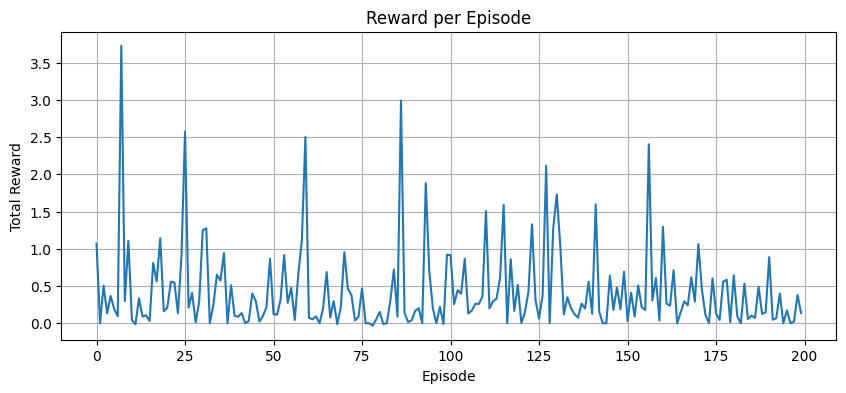

In [19]:
import matplotlib.pyplot as plt

# Create environment and agent
env = TradingEnv(train_norm)
agent = DQNAgent()

EPISODES = 200
reward_history = []

print("Starting training...")
print("-" * 40)

for episode in range(EPISODES):
    state = env.reset()
    total_reward = 0
    done = False

    while not done:
        # Agent picks action
        action = agent.select_action(state)

        # Game responds
        next_state, reward, done, _ = env.step(action)

        # Agent writes in diary
        agent.store_experience(state, action, reward, next_state, done)

        # Agent learns from diary
        agent.train_step()

        # Move to next day
        state = next_state
        total_reward += reward

    # Update target network every 10 episodes
    if episode % 10 == 0:
        agent.update_target_network()

    reward_history.append(total_reward)

    if episode % 10 == 0:
        print(f"Episode {episode:3d} | Total Reward: {total_reward:.4f} | Epsilon: {agent.epsilon:.3f}")

print("-" * 40)
print("Training complete!")

# Plot reward curve
plt.figure(figsize=(10, 4))
plt.plot(reward_history)
plt.title("Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

##  Backtesting on Test Data

Initial Portfolio: ₹100,000.00
Final Portfolio:   ₹103,798.19
Total Return:      3.80%
Max Drawdown:      4.66%
Total Trades:      479


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


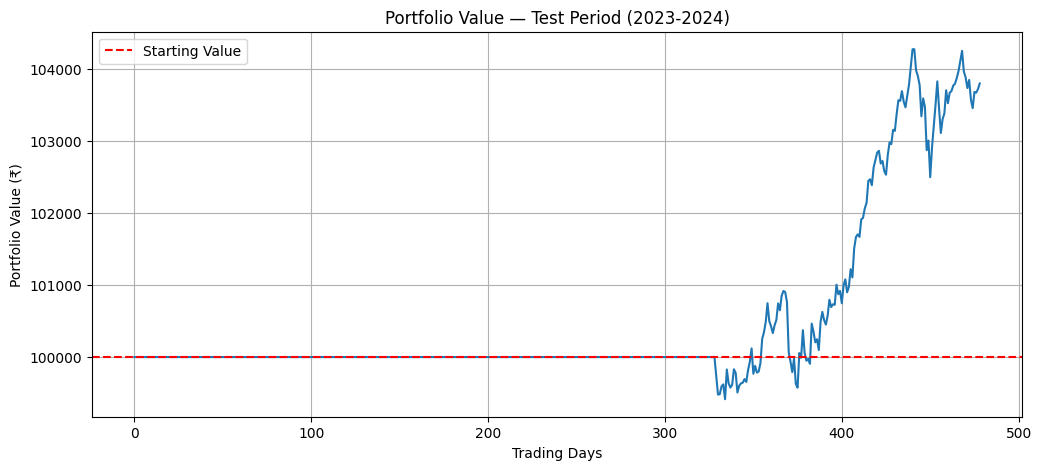

In [22]:
# Run trained agent on unseen test data (2023-2024)
test_env = TradingEnv(test_norm)
state = test_env.reset()

portfolio_history = []
trade_actions = []
done = False

# Store original prices for trade logging (not normalized)
test_prices = test_df.reset_index()

while not done:
    # Agent picks action (no exploration — pure exploitation)
    action = agent.select_action(state)
    next_state, reward, done, _ = test_env.step(action)

    # Record portfolio value
    portfolio_history.append(test_env.portfolio_value)

    # Record trade action
    current_idx = test_env.current_step - 1
    action_name = ["HOLD", "BUY", "SELL"][action]

    if current_idx < len(test_prices):
        trade_actions.append({
            "date": str(test_prices.iloc[current_idx]["Date"])[:10],
            "action": action_name,
            "portfolio_value": round(test_env.portfolio_value, 2)
        })

    state = next_state

# Calculate final metrics
initial_value = 100000
final_value = portfolio_history[-1]
total_return = ((final_value - initial_value) / initial_value) * 100
max_drawdown = ((max(portfolio_history) - min(portfolio_history)) / max(portfolio_history)) * 100

print(f"Initial Portfolio: ₹{initial_value:,.2f}")
print(f"Final Portfolio:   ₹{final_value:,.2f}")
print(f"Total Return:      {total_return:.2f}%")
print(f"Max Drawdown:      {max_drawdown:.2f}%")
print(f"Total Trades:      {len(trade_actions)}")

# Plot portfolio performance
plt.figure(figsize=(12, 5))
plt.plot(portfolio_history)
plt.axhline(y=initial_value, color='r', linestyle='--', label='Starting Value')
plt.title("Portfolio Value — Test Period (2023-2024)")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value (₹)")
plt.legend()
plt.grid(True)
plt.show()

##  Save

In [23]:
import torch
import json

# 1. Save model weights
torch.save(agent.model.state_dict(), "model.pth")
print("✅ model.pth saved!")

# 2. Save results as JSON
results = {
    "reward_history": [round(float(r), 4) for r in reward_history],
    "portfolio_history": [round(float(p), 2) for p in portfolio_history],
    "trade_actions": trade_actions
}

with open("results.json", "w") as f:
    json.dump(results, f)

print("✅ results.json saved!")
print(f"\nSummary:")
print(f"  Reward history: {len(reward_history)} episodes")
print(f"  Portfolio history: {len(portfolio_history)} days")
print(f"  Trade actions: {len(trade_actions)} trades")

✅ model.pth saved!
✅ results.json saved!

Summary:
  Reward history: 200 episodes
  Portfolio history: 479 days
  Trade actions: 479 trades
